In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Define the transformation
# VAEs often work well with pixel values scaled between 0 and 1, which ToTensor() handles automatically.
transform = transforms.Compose([
    transforms.ToTensor() 
])

# 2. Download and load the training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=True,
    download=True, 
    transform=transform
)

# 3. Create the DataLoader
batch_size = 16
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size,
    shuffle=True, 
    num_workers=2
)

# 4. Define the human-readable class names (Fashion-MNIST has 10 classes)
fashion_classes = (
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
)

print(f"Total training images: {len(train_dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.2MB/s]

Total training images: 60000


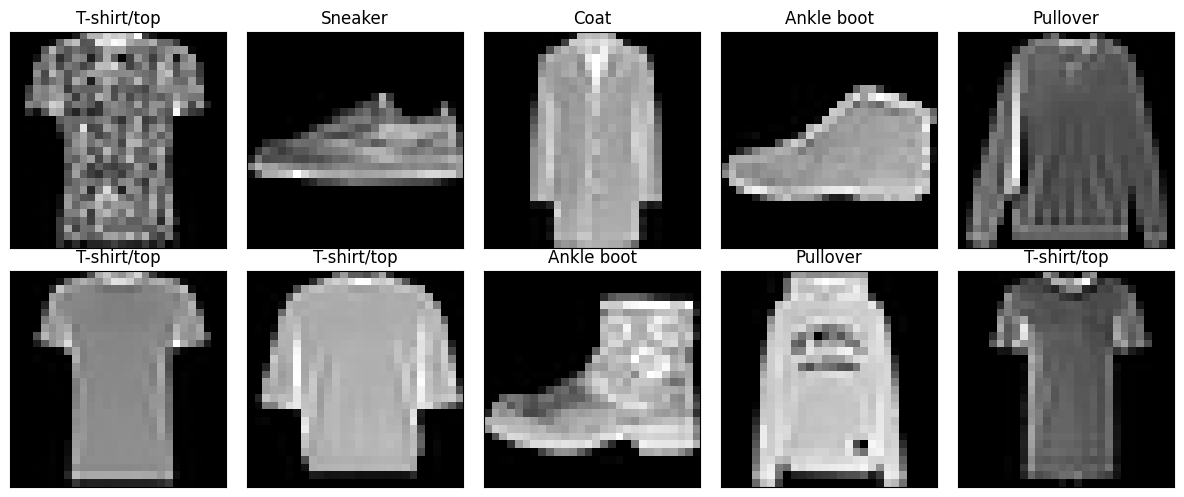

In [3]:
# Fetch a single batch of images and labels
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a figure to display the images
fig = plt.figure(figsize=(12, 5))

# Plot the first 10 images in the batch
for idx in range(10):
    ax = fig.add_subplot(2, 5, idx + 1, xticks=[], yticks=[])
    ax.imshow(images[idx].squeeze(), cmap='gray')
    
    # Set the title to the corresponding class name
    ax.set_title(fashion_classes[labels[idx]])

plt.tight_layout()
plt.show()

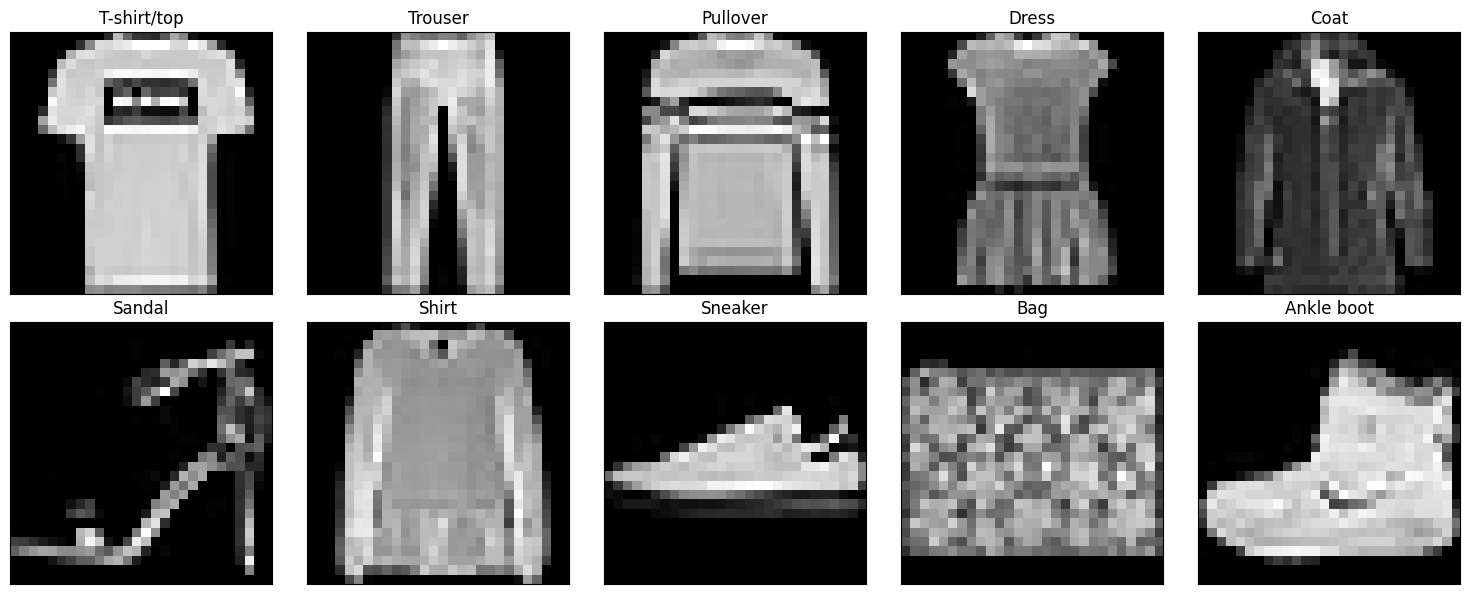

In [5]:
import matplotlib.pyplot as plt

# 1. Dictionary to store exactly one image per class
class_images = {}

# 2. Iterate through the raw dataset 
for image, label in train_dataset:
    # If we haven't seen this label yet, save the image
    if label not in class_images:
        class_images[label] = image
        
    # Stop searching once we have all 10 classes (labels 0 through 9)
    if len(class_images) == 10:
        break

# 3. Create a figure to display the images
fig = plt.figure(figsize=(15, 6))

# 4. Plot them in order of their class index (0 to 9)
for label in range(10):
    ax = fig.add_subplot(2, 5, label + 1, xticks=[], yticks=[])
    
    # Squeeze the tensor to remove the channel dimension: (1, 28, 28) -> (28, 28)
    img = class_images[label].squeeze()
    
    ax.imshow(img, cmap='gray')
    ax.set_title(fashion_classes[label])

plt.tight_layout()
plt.show()

In [6]:
# Load the test dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

In [7]:
import torch

print("--- 1. Dataset Dimensions ---")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples:  {len(test_dataset)}")

# Grab one sample to check the exact tensor shape
sample_img, sample_label = train_dataset[0]
print(f"Image tensor shape: {sample_img.shape} -> (Channels, Height, Width)")

print("\n--- 2. Class Distribution (Training Set) ---")
# PyTorch stores the raw labels in the .targets attribute
class_counts = torch.bincount(train_dataset.targets)

# Print the count for each class
for i, count in enumerate(class_counts):
    print(f"{fashion_classes[i]:<15}: {count.item()} images")

print("\n--- 3. Pixel Value Statistics ---")
# To get accurate stats, we'll stack all training images into one giant tensor.
# Note: This is safe for Fashion-MNIST (~188 MB), but for larger datasets, 
# you would calculate this iteratively in batches.
print("Calculating pixel statistics... (this might take a few seconds)")
all_images = torch.stack([img for img, _ in train_dataset])

print(f"Global Minimum: {all_images.min().item():.4f}")
print(f"Global Maximum: {all_images.max().item():.4f}")
print(f"Global Mean:    {all_images.mean().item():.4f}")
print(f"Global Std Dev: {all_images.std().item():.4f}")

--- 1. Dataset Dimensions ---
Training samples: 60000
Testing samples:  10000
Image tensor shape: torch.Size([1, 28, 28]) -> (Channels, Height, Width)

--- 2. Class Distribution (Training Set) ---
T-shirt/top    : 6000 images
Trouser        : 6000 images
Pullover       : 6000 images
Dress          : 6000 images
Coat           : 6000 images
Sandal         : 6000 images
Shirt          : 6000 images
Sneaker        : 6000 images
Bag            : 6000 images
Ankle boot     : 6000 images

--- 3. Pixel Value Statistics ---
Calculating pixel statistics... (this might take a few seconds)
Global Minimum: 0.0000
Global Maximum: 1.0000
Global Mean:    0.2860
Global Std Dev: 0.3530
